<a href="https://colab.research.google.com/github/SOURAV143-BIT/HEART_DISEASE_PREDICTION-USING-MACHINE-LEARNING/blob/main/HEART_DISEASE_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df=pd.read_csv("/content/dataset.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


getting the info about dataset

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [48]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


finding the corelation b/w fields

In [49]:
corr_matrix=df.corr()
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


visualising the correlation

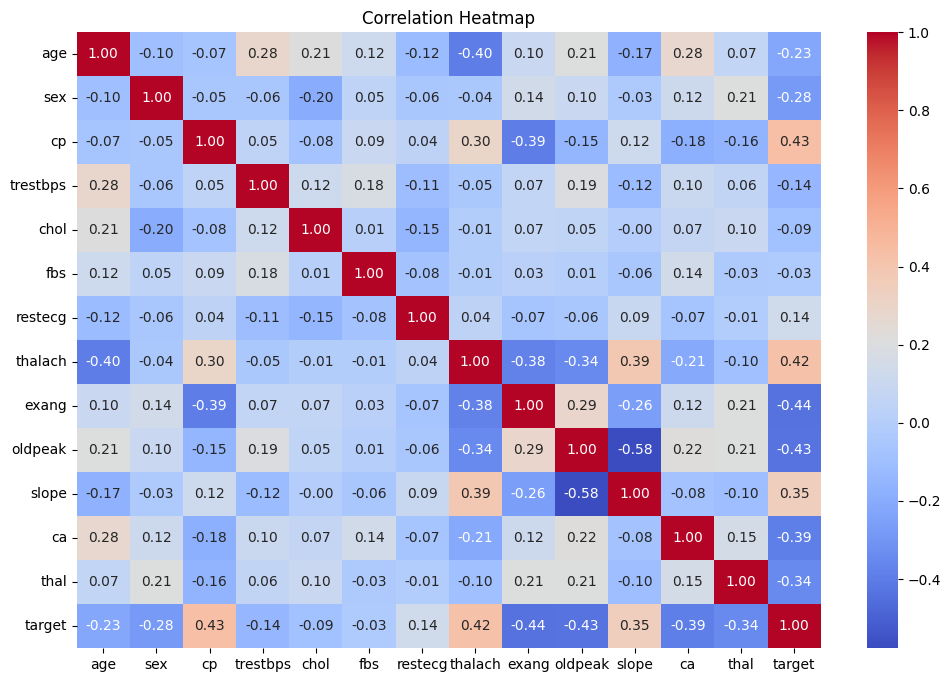

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


VISUALISING THE NO. OF PATEINTS HAVING HEART DIESEASE AND NOT HAVING HEART DISEASE

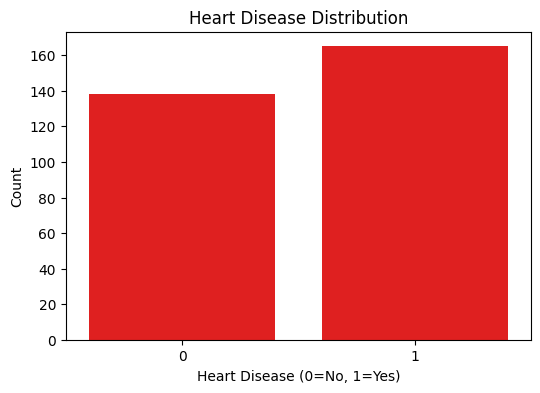

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df,color='red')
plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

visualising the age and whether the patient has disease or not

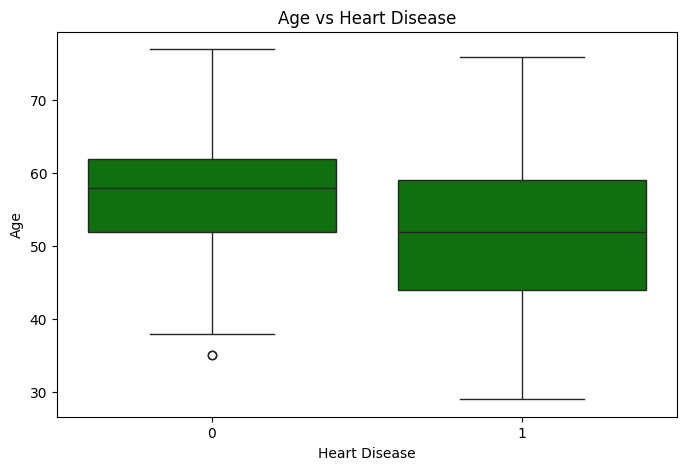

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='age', data=df,color='green')
plt.title('Age vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Age')
plt.show()

SPLIITING THE DATA INTO TRAINING AND TEST DATA SET

In [53]:
from sklearn.model_selection import train_test_split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42)

IMPORTING THE LIBRARIES I NEED FOR IMPORTING MODEL AND FOR EVALUTAING ITS PERFORMANCE

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score

BUILDING A LOGISTIC REGRESSION MODEL

In [55]:
print("\n     LOGISTIC REGRESSION     ")

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_cm = confusion_matrix(y_test, lr_pred)
lr_acc = accuracy_score(y_test, lr_pred)

print("Confusion Matrix:")
print(lr_cm)

print("\nAccuracy:", lr_acc)

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))





     LOGISTIC REGRESSION     
Confusion Matrix:
[[32  9]
 [ 8 42]]

Accuracy: 0.8131868131868132

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        41
           1       0.82      0.84      0.83        50

    accuracy                           0.81        91
   macro avg       0.81      0.81      0.81        91
weighted avg       0.81      0.81      0.81        91



BUILDING A RANDOM FOREST MODEL

In [56]:

#  RANDOM FOREST

print("\n      RANDOM FOREST      ")

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_cm = confusion_matrix(y_test, rf_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Confusion Matrix:")
print(rf_cm)

print("\nAccuracy:", rf_acc)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


      RANDOM FOREST      
Confusion Matrix:
[[33  8]
 [ 8 42]]

Accuracy: 0.8241758241758241

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        41
           1       0.84      0.84      0.84        50

    accuracy                           0.82        91
   macro avg       0.82      0.82      0.82        91
weighted avg       0.82      0.82      0.82        91



BUILDING A DECISION TREE MODEL

In [57]:
#  DECISION TREE

print("\n     DECISION TREE      ")

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_cm = confusion_matrix(y_test, dt_pred)
dt_acc = accuracy_score(y_test, dt_pred)

print("Confusion Matrix:")
print(dt_cm)

print("\nAccuracy:", dt_acc)

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))



     DECISION TREE      
Confusion Matrix:
[[32  9]
 [15 35]]

Accuracy: 0.7362637362637363

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.78      0.73        41
           1       0.80      0.70      0.74        50

    accuracy                           0.74        91
   macro avg       0.74      0.74      0.74        91
weighted avg       0.74      0.74      0.74        91



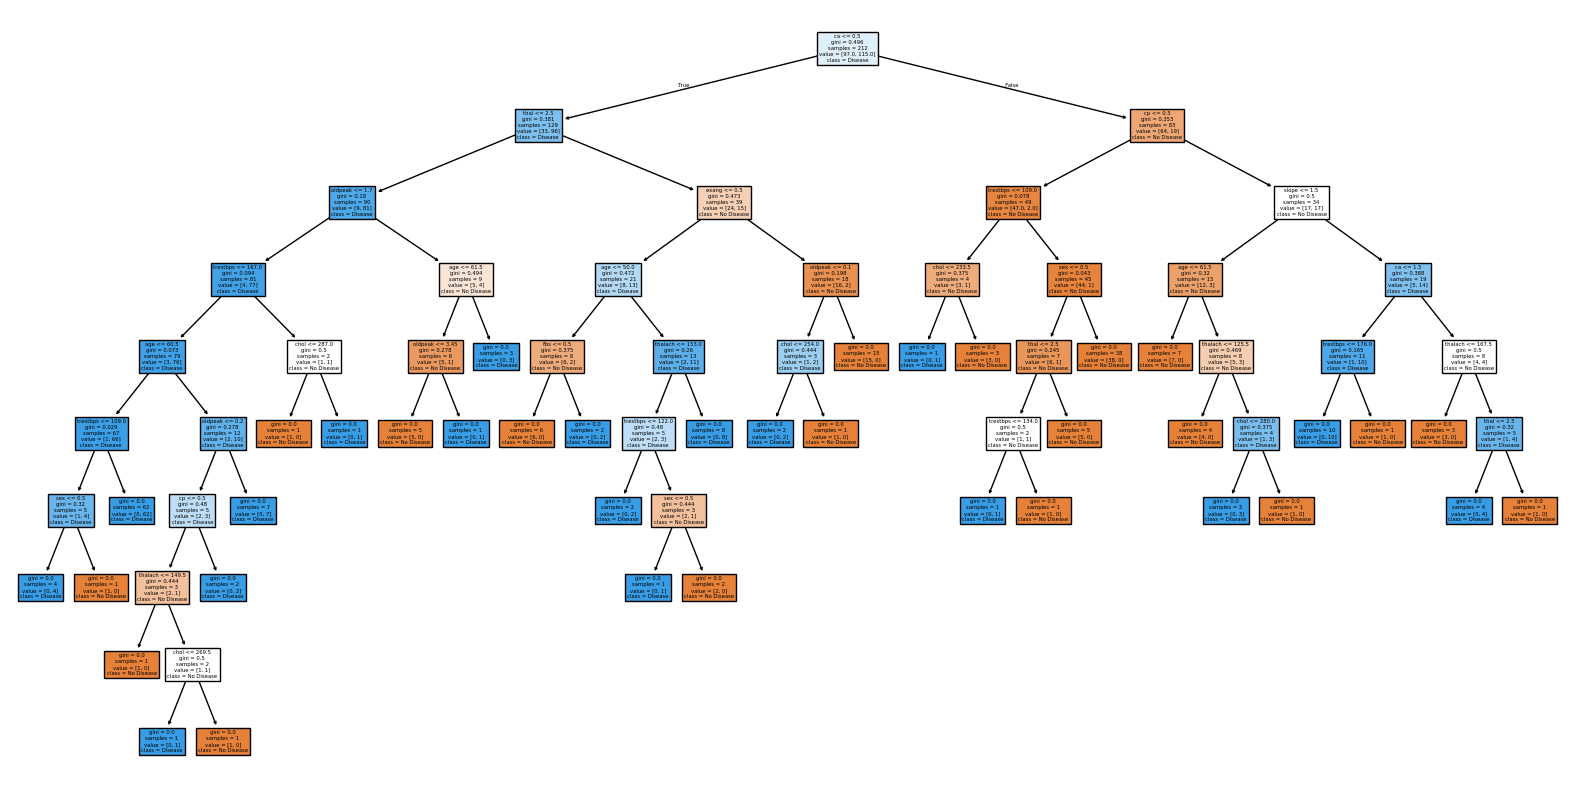

In [58]:
# DECISION TREE VISUALIZATION

from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(dt,feature_names=X.columns,class_names=['No Disease','Disease'],filled=True)
plt.show()


COMPARING THE MODELS PERFORMANCE

In [59]:
#MODEL COMPARISON

results = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy': [accuracy_score(y_test, lr_pred),accuracy_score(y_test, dt_pred), accuracy_score(y_test, rf_pred)],
    'Precision': [precision_score(y_test, lr_pred),precision_score(y_test, dt_pred),precision_score(y_test, rf_pred)],
    'Recall': [recall_score(y_test, lr_pred),recall_score(y_test, dt_pred),recall_score(y_test, rf_pred)],
    'F1 Score': [f1_score(y_test, lr_pred),f1_score(y_test, dt_pred),f1_score(y_test, rf_pred)]})

print("\n===== MODEL COMPARISON =====")
print(results)



===== MODEL COMPARISON =====
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression  0.813187   0.823529    0.84  0.831683
1        Decision Tree  0.736264   0.795455    0.70  0.744681
2        Random Forest  0.824176   0.840000    0.84  0.840000


VISUALISING THE CONFUSION MATRIX OF MODELS USING HEATMAP

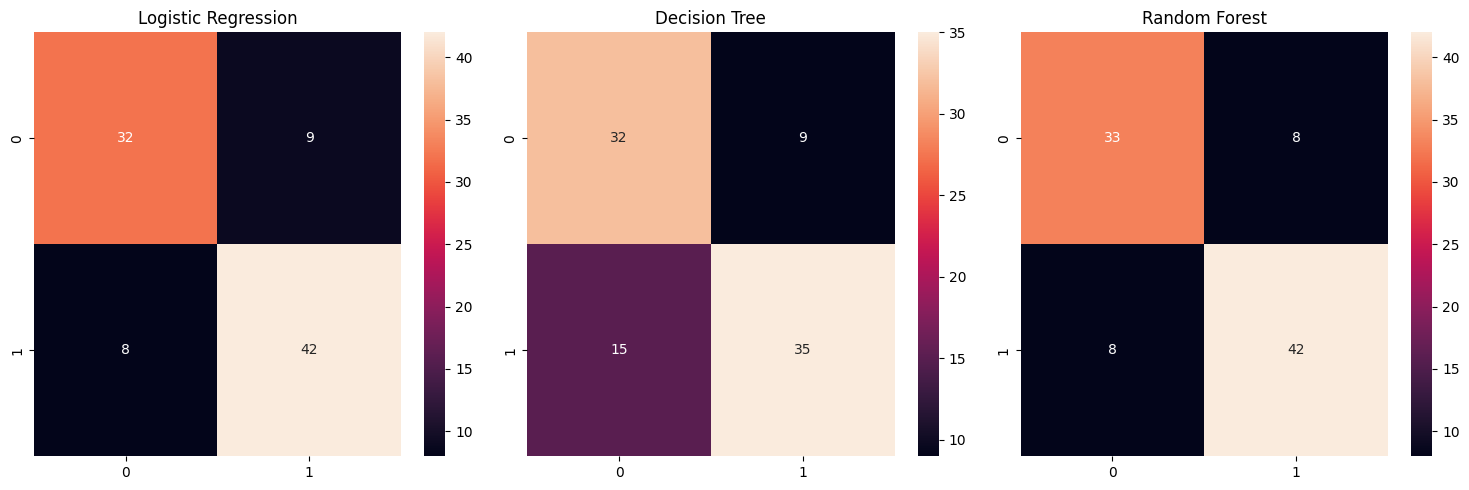

In [60]:

# CONFUSION MATRIX HEATMAPS

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.heatmap(lr_cm,annot=True,fmt='d',ax=axes[0])
axes[0].set_title('Logistic Regression')

sns.heatmap(dt_cm,annot=True,fmt='d',ax=axes[1])
axes[1].set_title('Decision Tree')

sns.heatmap(rf_cm,annot=True,fmt='d',ax=axes[2])
axes[2].set_title('Random Forest')

plt.tight_layout()
plt.show()

SELECTING THE BEST MODEL BASED ON ACCURACY

In [61]:
# best model
best_model = results.loc[results['Accuracy'].idxmax()]

print("\n===== BEST MODEL =====")
print(best_model)


===== BEST MODEL =====
Model        Random Forest
Accuracy          0.824176
Precision             0.84
Recall                0.84
F1 Score              0.84
Name: 2, dtype: object
